# Training
因為要確切比較模型 所以直接改動epochs去看生成效果的各組數據比較

In [1]:
import numpy as np
import torch

# ============================================================
# OU Dataset with random t
# x0 ~ N(10, 2)
# dX_t = - beta X_t dt + sigma dW_t
# ============================================================

mu0 = 10.0
var0 = 2.0
std0 = np.sqrt(var0)

beta = 1.0
sigma = np.sqrt(beta * 2.0)

T = 5.0
eps_t = 1e-3

N = 10000

# x0 ~ N(mu0, var0)
x0_np = np.random.normal(
    mu0,
    std0,
    N
).astype(np.float32)

# random t ~ Uniform(eps_t, T)
t_np = np.random.uniform(
    eps_t,
    T,
    N
).astype(np.float32)

# OU conditional mean and variance
a_t_np = np.exp(-beta * t_np).astype(np.float32)

cond_var_t_np = (
    sigma**2 / (2 * beta)
    * (1 - np.exp(-2 * beta * t_np))
).astype(np.float32)

cond_std_t_np = np.sqrt(cond_var_t_np).astype(np.float32)

# xt | x0
eps_np = np.random.randn(N).astype(np.float32)

xt_np = (
    a_t_np * x0_np
    + cond_std_t_np * eps_np
).astype(np.float32)

# OU marginal mean and variance
mu_t_np = (
    a_t_np * mu0
).astype(np.float32)

var_t_np = (
    (a_t_np**2) * var0
    + cond_var_t_np
).astype(np.float32)

# exact marginal score ∇ log p_t(x)
score_t_np = (
    -(xt_np - mu_t_np)
    / var_t_np
).astype(np.float32)

# conditional score ∇ log p(xt | x0)
cond_score_np = (
    -(xt_np - a_t_np * x0_np)
    / cond_var_t_np
).astype(np.float32)

# torch tensors
x0_train = torch.tensor(x0_np).view(-1, 1)
xt_train = torch.tensor(xt_np).view(-1, 1)
t_train = torch.tensor(t_np).view(-1, 1)

score_t_train = torch.tensor(score_t_np).view(-1, 1)
cond_score_train = torch.tensor(cond_score_np).view(-1, 1)

print("t range:", t_np.min(), t_np.max())
print("xt empirical mean:", xt_np.mean())
print("xt empirical var:", xt_np.var())
print("score empirical mean:", score_t_np.mean())
print("cond_score empirical mean:", cond_score_np.mean())

t range: 0.0015553635 4.9973392
xt empirical mean: 1.9872965
xt empirical var: 7.273156
score empirical mean: 0.003590196
cond_score empirical mean: 0.010048231


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.SiLU(),

            nn.Linear(64, 64),
            nn.SiLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ScoreNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

xt_train = xt_train.to(device)
t_train = t_train.to(device)
cond_score_train = cond_score_train.to(device)


In [3]:
import copy

# ============================================================
# Time-dependent OU training
# save models at different epochs
# ============================================================

T = 5.0
eps_t = 0.05

epochs = 300
batch_size = 2048

save_epochs =[10, 20, 50, 100, 150, 200, 250, 300]
saved_models = {}

L_ESM_history = []
L_ISM_history = []
L_DSM_history = []
I_DSM_history = []

for epoch in range(1, epochs + 1):

    # sample x0
    x0 = (
        torch.randn(batch_size, 1, device=device)
        * np.sqrt(var0)
        + mu0
    )

    # sample t ~ Uniform(eps_t, T)
    t_batch = (
        eps_t
        + (T - eps_t) * torch.rand(batch_size, 1, device=device)
    )

    # OU coefficients
    a_t = torch.exp(-beta * t_batch)

    cond_var_t = (
        sigma**2 / (2 * beta)
        * (1 - torch.exp(-2 * beta * t_batch))
    )

    cond_std_t = torch.sqrt(cond_var_t)

    # generate xt
    eps = torch.randn_like(x0)

    xt = (
        a_t * x0
        + cond_std_t * eps
    )

    xt.requires_grad_(True)

    # marginal distribution p_t(x)
    mu_t = a_t * mu0

    var_t = (
        (a_t**2) * var0
        + cond_var_t
    )

    # exact marginal score
    score_t = (
        -(xt - mu_t)
        / var_t
    )

    # conditional score
    cond_score = (
        -(xt - a_t * x0)
        / cond_var_t
    )

    # network prediction
    pred_score = model(xt, t_batch)

    # L_ESM
    L_ESM = ((pred_score - score_t) ** 2).mean()

    # L_ISM
    div_score = torch.autograd.grad(
        outputs=pred_score.sum(),
        inputs=xt,
        create_graph=True
    )[0]

    L_ISM = (
        pred_score**2
        + 2 * div_score
    ).mean()

    # L_DSM
    L_DSM = ((pred_score - cond_score) ** 2).mean()

    # I_DSM
    I_DSM = (
        pred_score**2
        - pred_score * cond_score
    ).mean()

    # train
    loss = L_ESM

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # record
    L_ESM_history.append(L_ESM.item())
    L_ISM_history.append(L_ISM.item())
    L_DSM_history.append(L_DSM.item())
    I_DSM_history.append(I_DSM.item())

    # save model checkpoint
    if epoch in save_epochs:
        saved_models[epoch] = copy.deepcopy(model.state_dict())

    # print
    if epoch in save_epochs:# or epoch % 50 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"L_ESM = {L_ESM.item():.8f} | "
            f"L_ISM = {L_ISM.item():.8f} | "
            f"L_DSM = {L_DSM.item():.8f} | "
            f"I_DSM = {I_DSM.item():.8f}"
        )

Epoch   10 | L_ESM = 0.73168123 | L_ISM = -0.22373481 | L_DSM = 1.00788331 | I_DSM = -0.05376976
Epoch   20 | L_ESM = 0.50698888 | L_ISM = -0.42841935 | L_DSM = 0.84629166 | I_DSM = -0.13586262
Epoch   50 | L_ESM = 0.19001406 | L_ISM = -0.71465498 | L_DSM = 0.46122327 | I_DSM = -0.03726573
Epoch  100 | L_ESM = 0.07912476 | L_ISM = -0.86120307 | L_DSM = 0.40569597 | I_DSM = -0.04142836
Epoch  150 | L_ESM = 0.02421655 | L_ISM = -0.95115721 | L_DSM = 0.35455415 | I_DSM = -0.04160446
Epoch  200 | L_ESM = 0.00816423 | L_ISM = -0.92619532 | L_DSM = 0.26494879 | I_DSM = -0.00657815
Epoch  250 | L_ESM = 0.00258150 | L_ISM = -0.95175654 | L_DSM = 0.33743706 | I_DSM = -0.00168617
Epoch  300 | L_ESM = 0.00237637 | L_ISM = -0.96899194 | L_DSM = 0.29428723 | I_DSM = -0.01278877


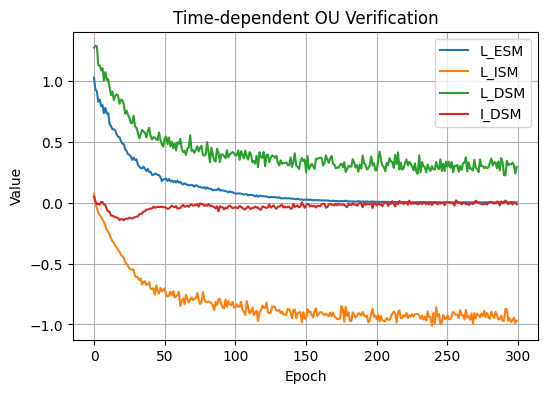

In [4]:
plt.figure(figsize=(6,4))

plt.plot(L_ESM_history, label='L_ESM')
plt.plot(L_ISM_history, label='L_ISM')
plt.plot(L_DSM_history, label='L_DSM')
plt.plot(I_DSM_history, label='I_DSM')

plt.xlabel("Epoch")
plt.ylabel("Value")

plt.title("Time-dependent OU Verification")

plt.legend()
plt.grid(True)

plt.show()

# Reverse

In [5]:
results = []

steps = 1000
dt = T / steps
epoch_list = [10, 20, 50, 100, 150, 200, 250, 300]
num_samples = 10000

for epoch in epoch_list:

    model.load_state_dict(saved_models[epoch])
    model.eval()

    # start from p_T

    a_T = np.exp(-beta * T)

    cond_var_T = (
        sigma**2/(2*beta)
        * (1 - np.exp(-2*beta*T))
    )

    mu_T = a_T * mu0

    var_T = (
        (a_T**2)*var0
        + cond_var_T
    )

    x = (
        torch.randn(num_samples,1,device=device)
        * np.sqrt(var_T)
        + mu_T
    )

    with torch.no_grad():

        for i in range(steps):

            t_now = T - i*dt
            t_now = max(t_now,1e-5)

            t_tensor = (
                torch.ones_like(x)
                * t_now
            )

            score = model(x,t_tensor)

            noise = torch.randn_like(x)

            x = (
                x
                + (beta*x + sigma**2*score)*dt
                + sigma*np.sqrt(dt)*noise
            )

    samples_reverse = (
        x.cpu().numpy().flatten()
    )

    results.append({
        "epoch": epoch,
        "reverse_mean": samples_reverse.mean(),
        "reverse_std": samples_reverse.std(),
        "mean_error":
            abs(samples_reverse.mean()-mu0),
        "std_error":
            abs(samples_reverse.std()-np.sqrt(var0))
    })

import pandas as pd
df_results = pd.DataFrame(results)
df_results


,epoch,reverse_mean,reverse_std,mean_error,std_error
0,10,12.954553,55.160553,2.954553,53.746339
1,20,19.694574,31.316071,9.694574,29.901857
2,50,9.377340,5.411627,0.622660,3.997413
3,100,9.596770,4.787675,0.403230,3.373462
4,150,9.474095,11.390537,0.525905,9.976324
5,200,9.915401,1.835826,0.084599,0.421612
6,250,9.939157,1.715345,0.060843,0.301132
7,300,9.984854,1.456506,0.015146,0.042292


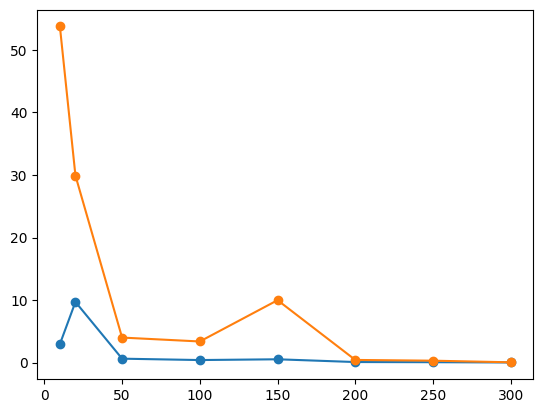

In [6]:
plt.plot(
    df_results["epoch"],
    df_results["mean_error"],
    marker="o",
    label="mean error"
)

plt.plot(
    df_results["epoch"],
    df_results["std_error"],
    marker="o",
    label="std error"
)

# Reverse 2

In [7]:
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Settings
# ============================================================

T = 5.0
beta = 1.0
mu0 = 10.0
var0 = 2.0
sigma = np.sqrt(2.0)

num_samples = 10000
num_eval = 10000
steps = 1000
dt = T / steps

epoch_list = [10, 20, 50, 100, 150, 200, 250, 300]

# ============================================================
# OU parameters
# ============================================================

def ou_params(t):
    a_t = np.exp(-beta * t)

    cond_var_t = (
        sigma**2 / (2 * beta)
        * (1 - np.exp(-2 * beta * t))
    )

    mu_t = a_t * mu0

    var_t = (
        (a_t**2) * var0
        + cond_var_t
    )

    return a_t, cond_var_t, mu_t, var_t


# ============================================================
# Compute indicators
# ============================================================

def compute_losses(model, x_eval, t_now):
    x_eval = x_eval.clone().detach().requires_grad_(True)
    t_tensor = torch.ones_like(x_eval) * t_now

    pred_score = model(x_eval, t_tensor)

    a_t, cond_var_t, mu_t, var_t = ou_params(t_now)

    marginal_score = -(x_eval - mu_t) / var_t

    post_mean = (
        mu0
        + (a_t * var0 / var_t)
        * (x_eval - mu_t)
    )

    post_var = (
        var0
        - (a_t**2 * var0**2) / var_t
    )

    x0_post = (
        post_mean
        + torch.sqrt(
            torch.tensor(post_var, device=device, dtype=x_eval.dtype)
        )
        * torch.randn_like(post_mean)
    )

    cond_score = -(x_eval - a_t * x0_post) / cond_var_t

    L_ESM = ((pred_score - marginal_score) ** 2).mean()
    L_DSM = ((pred_score - cond_score) ** 2).mean()

    div_score = torch.autograd.grad(
        outputs=pred_score.sum(),
        inputs=x_eval,
        create_graph=False,
        retain_graph=False
    )[0]

    L_ISM = (
        pred_score**2
        + 2 * div_score
    ).mean()

    I_DSM = (
        pred_score**2
        - pred_score * cond_score
    ).mean()

    return {
        "L_ESM": L_ESM.item(),
        "L_DSM": L_DSM.item(),
        "L_ISM": L_ISM.item(),
        "I_DSM": I_DSM.item(),
    }


# ============================================================
# Fixed evaluation data for indicators
# ============================================================

t_eval_for_loss = 1.0
a_eval, cond_var_eval, mu_eval, var_eval = ou_params(t_eval_for_loss)

x_eval_for_loss = (
    torch.randn(num_eval, 1, device=device)
    * np.sqrt(var_eval)
    + mu_eval
)




,epoch,reverse_mean,reverse_std,mean_error,std_error,L_ESM,L_DSM,L_ISM,I_DSM
0,10,14.184348,54.814159,4.184348,53.399946,0.796671,1.086175,-0.070629,0.058126
1,20,19.980652,31.544146,9.980652,30.129932,0.800829,1.075362,-0.064611,0.043388
2,50,9.524459,5.541565,0.475541,4.127351,0.537840,0.830761,-0.331558,-0.123240
3,100,9.633610,4.331539,0.366390,2.917326,0.210446,0.495257,-0.671435,-0.214277
4,150,9.372573,11.713382,0.627427,10.299168,0.056251,0.336111,-0.837874,-0.157327
5,200,9.913240,1.922117,0.086760,0.507904,0.013320,0.291019,-0.887868,-0.070740
6,250,9.895035,1.632956,0.104965,0.218742,0.005383,0.280179,-0.898198,-0.040586
7,300,9.985880,1.471561,0.014120,0.057347,0.003476,0.279673,-0.900660,-0.025395


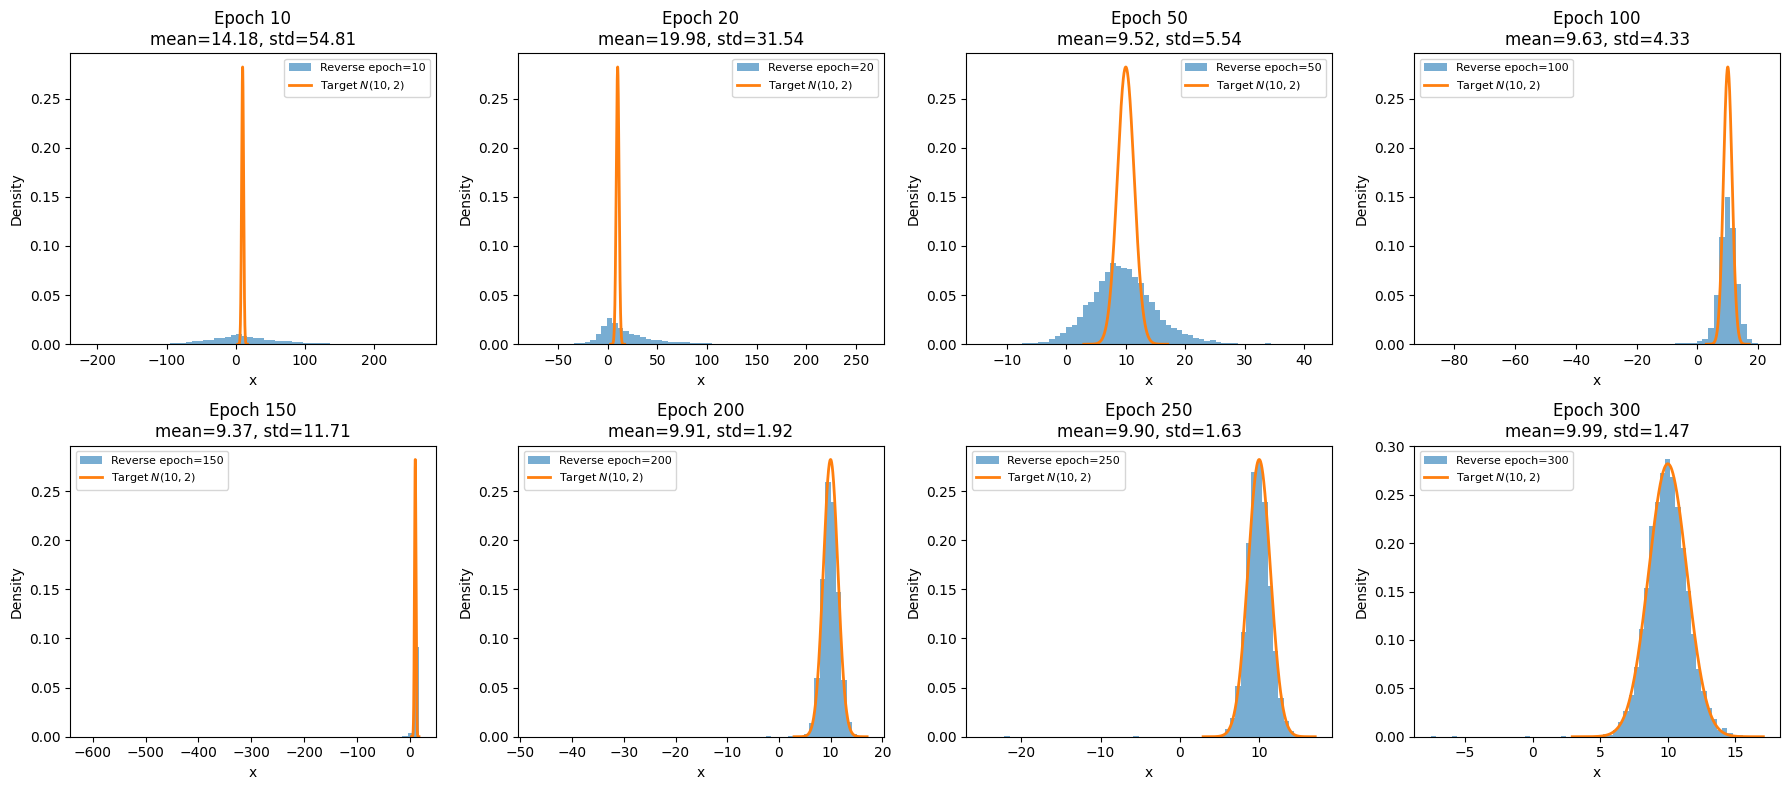

In [8]:
# ============================================================
# Reverse sampling + indicators for each epoch
# ============================================================

sample_dict = {}
reverse_results = []
indicator_results = []

for epoch in epoch_list:

    model.load_state_dict(saved_models[epoch])
    model.eval()

    # --------------------------------------------------------
    # Compute indicators
    # --------------------------------------------------------

    losses = compute_losses(
        model,
        x_eval_for_loss,
        t_eval_for_loss
    )

    indicator_results.append({
        "epoch": epoch,
        **losses
    })

    # --------------------------------------------------------
    # Reverse sampling
    # --------------------------------------------------------

    a_T, cond_var_T, mu_T, var_T = ou_params(T)

    x = (
        torch.randn(num_samples, 1, device=device)
        * np.sqrt(var_T)
        + mu_T
    )

    with torch.no_grad():

        for i in range(steps):

            t_now = T - i * dt
            t_now = max(t_now, 1e-5)

            t_tensor = torch.ones_like(x) * t_now

            score = model(x, t_tensor)
            noise = torch.randn_like(x)

            x = (
                x
                + (beta * x + sigma**2 * score) * dt
                + sigma * np.sqrt(dt) * noise
            )

    samples_reverse = x.detach().cpu().numpy().flatten()
    sample_dict[epoch] = samples_reverse

    reverse_results.append({
        "epoch": epoch,
        "reverse_mean": samples_reverse.mean(),
        "reverse_std": samples_reverse.std(),
        "mean_error": abs(samples_reverse.mean() - mu0),
        "std_error": abs(samples_reverse.std() - np.sqrt(var0)),
    })


df_reverse = pd.DataFrame(reverse_results)
df_indicators = pd.DataFrame(indicator_results)

df_summary = pd.merge(
    df_reverse,
    df_indicators,
    on="epoch",
    how="inner"
)

display(df_summary)


# ============================================================
# Plot reverse sampling figures side by side
# ============================================================

x_grid = np.linspace(
    mu0 - 5 * np.sqrt(var0),
    mu0 + 5 * np.sqrt(var0),
    500
)

p0_density = (
    1 / np.sqrt(2 * np.pi * var0)
    * np.exp(-(x_grid - mu0)**2 / (2 * var0))
)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, epoch in zip(axes, epoch_list):

    ax.hist(
        sample_dict[epoch],
        bins=60,
        density=True,
        alpha=0.6,
        label=f"Reverse epoch={epoch}"
    )

    ax.plot(
        x_grid,
        p0_density,
        linewidth=2,
        label=r"Target $N(10,2)$"
    )

    row = df_summary[df_summary["epoch"] == epoch].iloc[0]

    ax.set_title(
        f"Epoch {epoch}\n"
        f"mean={row['reverse_mean']:.2f}, std={row['reverse_std']:.2f}"
    )

    ax.set_xlabel("x")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

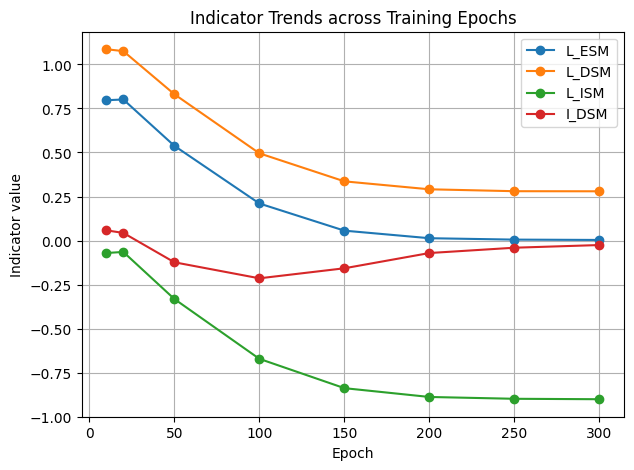

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(df_summary["epoch"], df_summary["L_ESM"], marker="o", label="L_ESM")
plt.plot(df_summary["epoch"], df_summary["L_DSM"], marker="o", label="L_DSM")
plt.plot(df_summary["epoch"], df_summary["L_ISM"], marker="o", label="L_ISM")
plt.plot(df_summary["epoch"], df_summary["I_DSM"], marker="o", label="I_DSM")

plt.xlabel("Epoch")
plt.ylabel("Indicator value")
plt.title("Indicator Trends across Training Epochs")
plt.legend()
plt.grid(True)
plt.show()

分兩張:

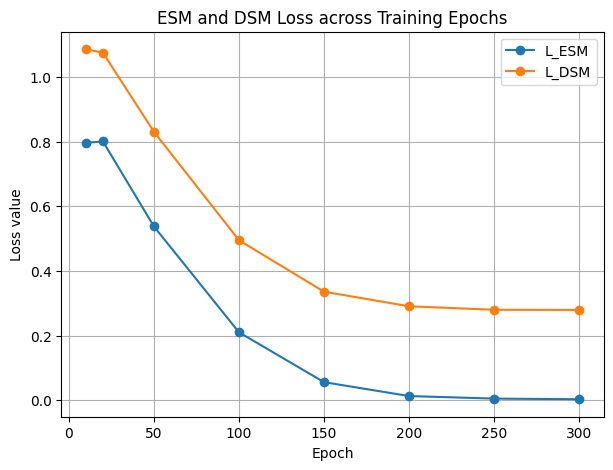

In [10]:
plt.figure(figsize=(7, 5))

plt.plot(df_summary["epoch"], df_summary["L_ESM"], marker="o", label="L_ESM")
plt.plot(df_summary["epoch"], df_summary["L_DSM"], marker="o", label="L_DSM")

plt.xlabel("Epoch")
plt.ylabel("Loss value")
plt.title("ESM and DSM Loss across Training Epochs")
plt.legend()
plt.grid(True)
plt.show()

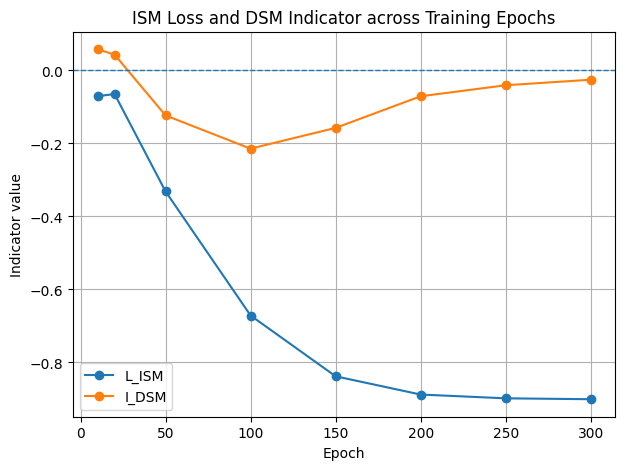

In [11]:
plt.figure(figsize=(7, 5))

plt.plot(df_summary["epoch"], df_summary["L_ISM"], marker="o", label="L_ISM")
plt.plot(df_summary["epoch"], df_summary["I_DSM"], marker="o", label="I_DSM")

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Epoch")
plt.ylabel("Indicator value")
plt.title("ISM Loss and DSM Indicator across Training Epochs")
plt.legend()
plt.grid(True)
plt.show()

# 最後面